In [1]:
import numpy as np
import scipy as sp
import mpmath as mp
import cmath as cmath

%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, Slider
from matplotlib import cm, colors



In [2]:
delta = 8/9

def A(x):
	return np.sqrt(1-delta**2*(1/np.cosh(x))**2)

r_minus_max = -A(0)
r_plus_min = A(0)

r_minus_max, r_plus_min

(-0.45812284729085123, 0.45812284729085123)

## Construction of alphas and betas for various (x,t) via moment conditions

In [3]:
def integrand(eta,endpts,p, branch:str):
	alpha = endpts[0]
	beta = endpts[1]
	if branch=='neg':
		# return eta**p*np.sqrt(eta-alpha)/np.sqrt(-(1-eta**2)*(eta-beta))*(p+1 + (eta*(3*eta**2-2*beta*eta-1)/(2*(1-eta**2)*(eta-beta))))
		# return np.sqrt(eta-alpha)*( ((p+1)*eta**p)/np.sqrt(-(1-eta**2)*(eta - beta)) - eta**(p+1)*(3*eta**2-2*beta*eta-1)/(2*((1-eta**2)*(beta-eta))**(3/2) ))
		return (p+1)*eta**p*np.sqrt((eta-alpha)/((1-eta**2)*(beta-eta))) - (1/2)*eta**(p+1)*((3*eta**2-2*beta*eta-1)/((1-eta**2)*(beta-eta)))*np.sqrt((eta-alpha)/((1-eta**2)*(beta-eta)))
	
	if branch=='pos':
		# return eta**p*np.sqrt(beta-eta)/np.sqrt((1-eta**2)*(eta-alpha))*(p+1 + (eta*(3*eta**2-2*alpha*eta-1)/(2*(1-eta**2)*(eta-alpha))))
		# return np.sqrt(beta - eta)*( ((p+1)*eta**p)/np.sqrt((1-eta**2)*(eta - alpha)) -  eta**(p+1)*(-3*eta**2+2*alpha*eta+1)/(2*((1-eta**2)*(eta-alpha))**(3/2)))
		return (p+1)*eta**p*np.sqrt((beta-eta)/((1-eta**2)*(eta-alpha))) - (1/2)*eta**(p+1)*((-3*eta**2+2*alpha*eta+1)/((1-eta**2)*(eta-alpha)))*np.sqrt((beta-eta)/((1-eta**2)*(eta-alpha)))
	else: 
		return ValueError('Need to specify branch.')


def total_moments(endpts:list,p,x,t, error=False):
	alpha = endpts[0]
	beta = endpts[1]
	
	# minus_moment = r_minus_max**(p+1)*np.sqrt(r_minus_max - alpha)/np.sqrt(-(1-r_minus_max**2)*(r_minus_max-beta)) - sp.integrate.quad(integrand, alpha,r_minus_max, args=(endpts,p,'neg'),points=alpha)[0]
	# plus_moment = -r_plus_min**(p+1)*np.sqrt(beta-r_plus_min)/np.sqrt((1-r_plus_min**2)*(r_plus_min-alpha)) - sp.integrate.quad(integrand, r_plus_min,beta, args=(endpts,p,'pos'), points=beta)[0]
	minus_moment = r_minus_max**(p+1)*np.sqrt(r_minus_max - alpha)/np.sqrt((1-r_minus_max**2)*(beta-r_minus_max)) - sp.integrate.quad(integrand, alpha,r_minus_max, args=(endpts,p,'neg'),points=alpha)[0]
	plus_moment = -r_plus_min**(p+1)*np.sqrt(beta-r_plus_min)/np.sqrt((1-r_plus_min**2)*(r_plus_min-alpha)) - sp.integrate.quad(integrand, r_plus_min,beta, args=(endpts,p,'pos'), points=beta)[0]
	sum_of_moments = minus_moment + plus_moment

	if x>=0: 
		sgnx=1

	if x<0:
		sgnx=-1
	if p==0:
		result = sgnx*sum_of_moments + x+ (alpha+beta)*t
	
	if p==1:
		result = sgnx*sum_of_moments + (1/2)*( (alpha+beta)*x + ( (3/2)*alpha**2 + (3/2)*beta**2 + alpha*beta )*t)

	# if error==True:
	# 	print(f"The error from numerically integrating the p={p} moment is {sum_of_moments[1]}.")
	
	return result
	# return np.array([np.real(result),np.imag(result).imag])



def total_moments_system(endpts,x,t, error=False):
	matrix = np.array([total_moments(endpts,0,x,t), total_moments(endpts,1,x,t)])
	return matrix



In [4]:
# testing for t=0 at
x0 = 10
t0= 0
alpha = -A(x0)
beta = A(x0)
endpts = [alpha,beta]

endpts, sp.optimize.fsolve(total_moments_system, [-A(x0),A(x0)], args=(x0,t0))


/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_47413/357255178.py:12: RuntimeWarning: invalid value encountered in sqrt
  return (p+1)*eta**p*np.sqrt((beta-eta)/((1-eta**2)*(eta-alpha))) - (1/2)*eta**(p+1)*((-3*eta**2+2*alpha*eta+1)/((1-eta**2)*(eta-alpha)))*np.sqrt((beta-eta)/((1-eta**2)*(eta-alpha)))
/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_47413/357255178.py:24: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  plus_moment = -r_plus_min**(p+1)*np.sqrt(beta-r_plus_min)/np.sqrt((1-r_plus_min**2)*(r_plus_min-alpha)) - sp.integrate.quad(integrand, r_plus_min,beta, args=(endpts,p,'pos'), points=beta)[0]
/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_47413/357255178.py:23: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestima

([-0.9999999967428683, 0.9999999967428683], array([-1.,  1.]))

In [5]:
# construction of x-t plane
x_window = 5
t_window = 10
num_xsamples = 100
num_tsamples = 40
X = np.linspace(-x_window, x_window, num_xsamples)
T = np.linspace(0, t_window, num_tsamples)

In [6]:
# checking that the moment conditions are satisfied for t=0 for all x in X
for i in range(len(X)):
	x0 = X[i]
	result = [total_moments([-A(x0),A(x0)],0,x0,0),total_moments([-A(x0),A(x0)],1,x0,0)]
	print(result)

[-7.442935157087049e-13, 0.0]
[-2.099920237697006e-11, 0.0]
[4.263256414560601e-14, 0.0]
[-1.2967404927621828e-12, 0.0]
[-1.0332179556371557e-11, 0.0]
[-2.362554596402333e-13, 0.0]
[8.745359991735313e-11, 0.0]
[-7.949196856316121e-13, 0.0]
[-7.815970093361102e-14, 0.0]
[6.927791673660977e-14, 0.0]
[-1.3922196728799463e-12, 0.0]
[-1.1228795671058833e-11, 0.0]
[-2.0872192862952943e-14, 0.0]
[-1.2523315717771766e-13, 0.0]
[-8.215650382226158e-13, 0.0]
[2.4424906541753444e-14, 0.0]
[-1.1723955140041653e-13, 0.0]
[-7.460698725481052e-14, 0.0]
[-1.354383272200721e-11, 0.0]
[2.531308496145357e-14, 0.0]
[-4.39648317751562e-14, 0.0]
[-1.2256862191861728e-13, 0.0]
[-5.329070518200751e-15, 0.0]
[-9.370282327836321e-14, 0.0]
[-9.192646643896296e-14, 0.0]
[3.597122599785507e-14, 0.0]
[-1.545430450278218e-13, 0.0]
[-1.0436096431476471e-13, 0.0]
[-3.5704772471945034e-13, 0.0]
[2.6645352591003757e-15, 0.0]
[-8.08242361927114e-14, 0.0]
[-7.907008381380365e-13, 0.0]
[-2.957634137601417e-13, 0.0]
[-1.034

In [7]:
init_alphas = np.zeros_like(X)
init_betas = np.zeros_like(X)


In [8]:
# solve for alphas and betas through root finding
for i in range(len(X)):
	x0 = X[i]
	roots = sp.optimize.fsolve(total_moments_system, [-A(x0),A(x0)], args=(x0,0))
	init_alphas[i] = roots[0]
	init_betas[i] = roots[1]

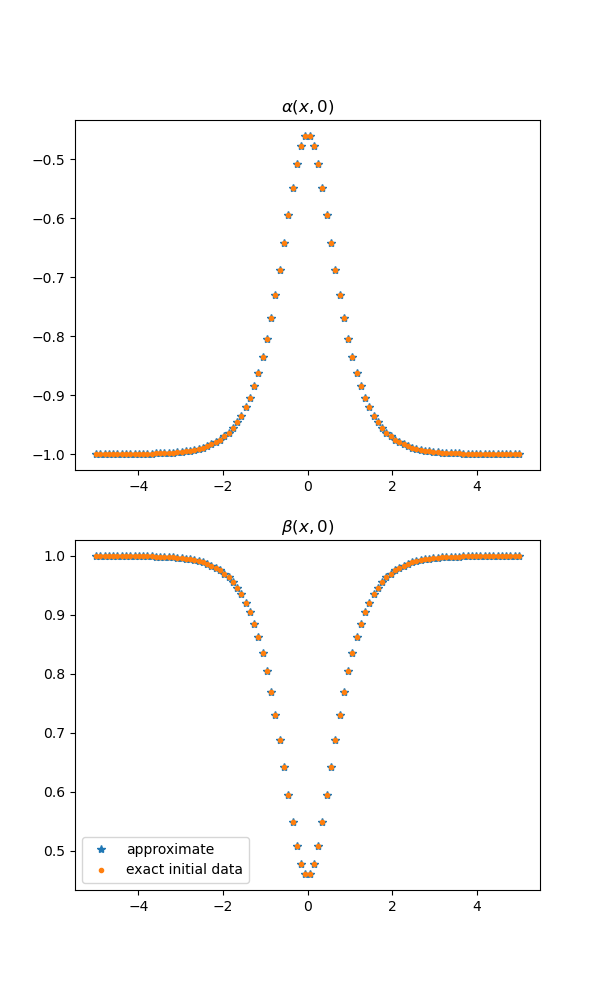

In [9]:
# plt.close()
fig0, axs0 = plt.subplots(2, figsize=(6,10))

# plot alphas from root finding
approx_alphas_plot = axs0[0].plot(X,init_alphas, label="approximate",marker='*',linestyle='none')

# plot alphas from A(x) 
exact_alphas_plot =axs0[0].plot(X, -A(X), label="exact initial data",marker='.',linestyle='none')

alphas_subtitle = axs0[0].set_title(r'$\alpha(x,0)$')
approx_betas_plot = axs0[1].plot(X,init_betas, label="approximate",marker='*',linestyle='none')
exact_betas_plot = axs0[1].plot(X, A(X), label="exact initial data",marker='.',linestyle='none')
betas_subtitle = axs0[1].set_title(r'$\beta(x,0)$')
plt.legend()
plt.show()

In [10]:
XX, TT = np.meshgrid(X,T)


In [11]:
# collect alphas and betas at later times
alphas = np.zeros_like(XX)
betas = np.zeros_like(XX)

# set initial data at t=0
alphas[0]=-A(X)
betas[0]=A(X)

# returns alphas for all in x in X at t=0
alphas[0]

array([-0.99992826, -0.9999122 , -0.99989255, -0.99986849, -0.99983906,
       -0.99980303, -0.99975894, -0.99970499, -0.99963896, -0.99955817,
       -0.99945929, -0.9993383 , -0.99919026, -0.99900912, -0.99878749,
       -0.99851635, -0.99818467, -0.99777896, -0.99728276, -0.996676  ,
       -0.99593416, -0.9950274 , -0.99391937, -0.99256585, -0.99091316,
       -0.98889623, -0.98643634, -0.98343854, -0.97978868, -0.97535009,
       -0.96995999, -0.96342576, -0.95552133, -0.94598415, -0.93451335,
       -0.92077022, -0.90438236, -0.88495364, -0.86208269, -0.83539339,
       -0.80458181, -0.76948452, -0.73017396, -0.68708609, -0.64118361,
       -0.59415049, -0.54858928, -0.50812875, -0.47722243, -0.46031352,
       -0.46031352, -0.47722243, -0.50812875, -0.54858928, -0.59415049,
       -0.64118361, -0.68708609, -0.73017396, -0.76948452, -0.80458181,
       -0.83539339, -0.86208269, -0.88495364, -0.90438236, -0.92077022,
       -0.93451335, -0.94598415, -0.95552133, -0.96342576, -0.96

In [12]:
# use root finding to solve for alphas and betas at later times. 
# use alpha and beta from previous time step as initial guess for next time step
for t_idx in range(1,num_tsamples):
	for x_idx in range(num_xsamples):
		result = sp.optimize.fsolve(total_moments_system, [alphas[t_idx-1][x_idx],betas[t_idx-1][x_idx]], args=(X[x_idx],T[t_idx]))
		alphas[t_idx][x_idx] = result[0]
		betas[t_idx][x_idx] = result[1]

/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_47413/357255178.py:24: RuntimeWarning: invalid value encountered in sqrt
  plus_moment = -r_plus_min**(p+1)*np.sqrt(beta-r_plus_min)/np.sqrt((1-r_plus_min**2)*(r_plus_min-alpha)) - sp.integrate.quad(integrand, r_plus_min,beta, args=(endpts,p,'pos'), points=beta)[0]
/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_47413/357255178.py:12: RuntimeWarning: invalid value encountered in sqrt
  return (p+1)*eta**p*np.sqrt((beta-eta)/((1-eta**2)*(eta-alpha))) - (1/2)*eta**(p+1)*((-3*eta**2+2*alpha*eta+1)/((1-eta**2)*(eta-alpha)))*np.sqrt((beta-eta)/((1-eta**2)*(eta-alpha)))
/var/folders/x8/s1k45xzs5vn1ms0n4nkfqykw0000gn/T/ipykernel_47413/357255178.py:24: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  plus_moment = -r_plus_min**(p+1)*np.sqrt(beta-r_plus_min)/np.sqrt((1-r_plus_min**2)*(r_plus_min-alpha)) - sp.

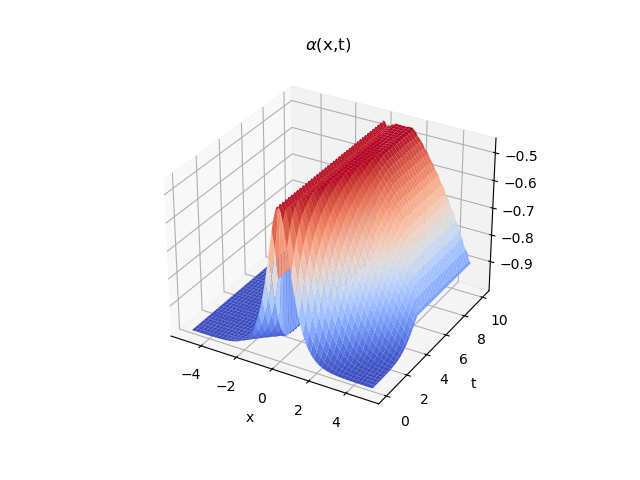

In [13]:
plt.close()
fig2, ax2 = plt.subplots(subplot_kw={"projection": "3d"}, num=' ')
ax2.clear()
alphas_xt_plot = ax2.plot_surface(XX,TT, alphas, cmap="coolwarm")
alphas_xt_plot_title = ax2.set_title(r"$\alpha$(x,t)")
alphas_x_label = ax2.set_xlabel('x')
alphas_y_label = ax2.set_ylabel('t')
plt.show()

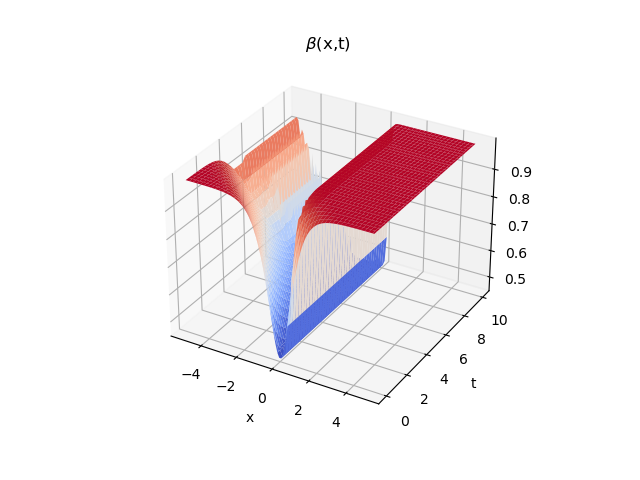

In [14]:
plt.close()
fig3, ax3 = plt.subplots(subplot_kw={"projection": "3d"}, num=' ')
ax3.clear()
betas_plot = ax3.plot_surface(XX,TT, betas, cmap='coolwarm')
betas_plot_title = ax3.set_title(r"$\beta$(x,t)")
betas_x_label = ax3.set_xlabel('x')
betas_y_label = ax3.set_ylabel('t')
plt.show()

0

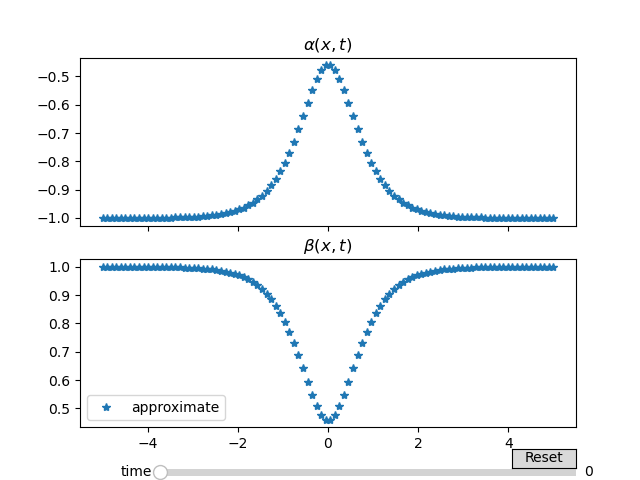

In [15]:
# graph of alpha(x) and beta(x) for fixed values of t
plt.close()
fig4, axs4 = plt.subplots(2, sharex=True, num=' ')
p4, = axs4[0].plot(X,alphas[0], label="approximate",marker='*',linestyle='none')
p4_title = axs4[0].set_title(r'$\alpha(x,t)$')
p5, = axs4[1].plot(X,betas[0], label="approximate",marker='*',linestyle='none')
p5_title = axs4[1].set_title(r'$\beta(x,t)$')
p4_legend = plt.legend()

ax_time = fig4.add_axes((0.25, 0.001, 0.65, 0.03))

time_slider = Slider(
    ax=ax_time,
    label="time",
    valinit=0,
    valmin =0,
    valmax=num_tsamples,
    valstep=range(num_tsamples),
    orientation="horizontal"
)

# The function to be called anytime a slider's value changes
def update(val):
    p4.set_ydata(alphas[:][time_slider.val])
    p5.set_ydata(betas[:][time_slider.val])
    fig4.canvas.draw_idle()


# register the update function with each slider
time_slider.on_changed(update)

# Create a `matplotlib.widgets.Button` to reset the sliders to initial values.
time_reset = fig4.add_axes((0.8, 0.025, 0.1, 0.04))
button = Button(time_reset, 'Reset', hovercolor='0.975')


def reset(event):
    time_slider.reset()
button.on_clicked(reset)

## Check Madelung equations

In [16]:
# store errors 
alphas_err = np.zeros_like(XX)
betas_err = np.zeros_like(XX)

# check how well the alphas and betas satisfy madelung equations
# forward difference in time, centered difference in space 
delta_t = T[1]-T[0]
delta_x = X[1] - X[0]

for tidx in range(num_tsamples-1): 
	for xidx in range(1,num_xsamples-1): # need to exclude boundary points due to centered difference approximation
		# print(xidx,tidx)
		alphas_err[tidx,xidx] = (alphas[tidx+1,xidx] - alphas[tidx,xidx])/delta_t + ((1/2)*alphas[tidx,xidx] + (3/2)*betas[tidx,xidx])*(alphas[tidx,xidx+1]-alphas[tidx,xidx-1])/(2*delta_x)
		betas_err[tidx,xidx] = (betas[tidx+1,xidx] - betas[tidx,xidx])/delta_t + ((1/2)*betas[tidx,xidx] + (3/2)*alphas[tidx,xidx])*(betas[tidx,xidx+1]-betas[tidx,xidx-1])/(2*delta_x)

print(f"The max error in alphas is {np.max(np.abs(alphas_err))} at (t,x) = ({np.unravel_index(np.argmax(np.abs(alphas_err)), np.shape(alphas_err))}).")
print(f"The max error in betas is {np.max(np.abs(betas_err))} at (t,x) = ({np.unravel_index(np.argmax(np.abs(betas_err)), np.shape(betas_err))}).")

The max error in alphas is 0.6087196027080705 at (t,x) = ((4, 46)).
The max error in betas is 0.7419903521814583 at (t,x) = ((25, 11)).


0

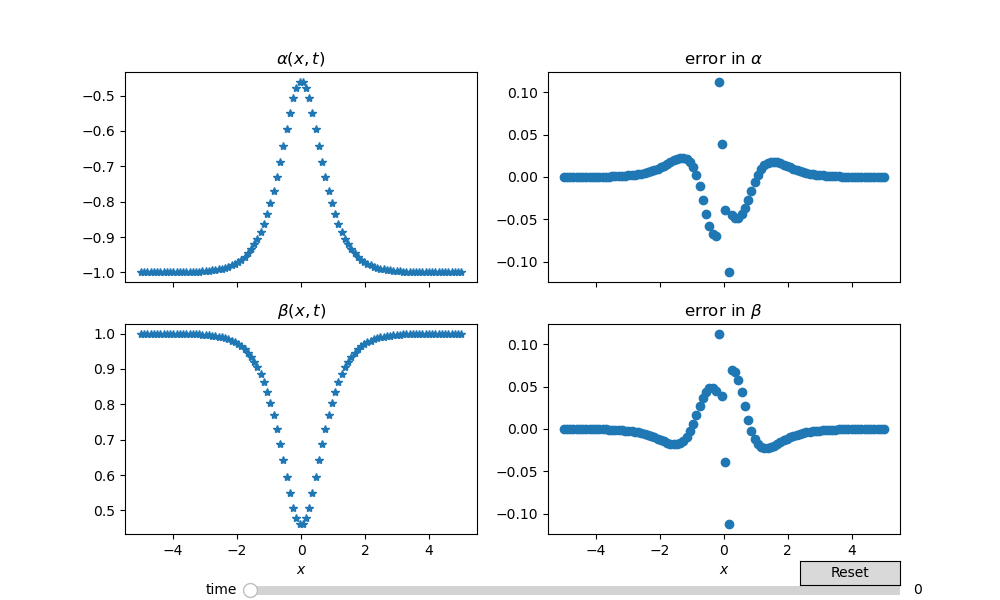

In [17]:
# graph of alpha(x) for fixed values of t

plt.close()
fig5, axs5 = plt.subplots(2,2, sharex= True, figsize=(10,6),num=' ')
p5, = axs5[0,0].plot(X,alphas[0], label="alpha",marker='*',linestyle='none')
p5_title = axs5[0,0].set_title(r'$\alpha(x,t)$')
p5_err, = axs5[0,1].plot(X,alphas_err[0], label="error",marker='o',linestyle='none')
p5_err_title = axs5[0,1].set_title(r'error in $\alpha$')
p6, = axs5[1,0].plot(X,betas[0], label="beta",marker='*',linestyle='none')
p6_title = axs5[1,0].set_title(r'$\beta(x,t)$')
p6_err, = axs5[1,1].plot(X,betas_err[0], label="error",marker='o',linestyle='none')
p6_err_title = axs5[1,1].set_title(r'error in $\beta$')
p5_x_label = axs5[1,0].set_xlabel(r'$x$')
p6_x_label = axs5[1,1].set_xlabel(r'$x$')

ax_time = fig5.add_axes((0.25, 0.001, 0.65, 0.03))

time_slider = Slider(
    ax=ax_time,
    label="time",
    valinit=0,
    valmin =0,
    valmax=num_tsamples,
    valstep=range(num_tsamples),
    orientation="horizontal"
)

# The function to be called anytime a slider's value changes
def update(val):
        p5.set_ydata(alphas[:][time_slider.val])
        p5_err.set_ydata(alphas_err[time_slider.val][:])
        p6.set_ydata(betas[:][time_slider.val])
        p6_err.set_ydata(betas_err[time_slider.val][:])
        fig5.canvas.draw_idle()


# register the update function with each slider
time_slider.on_changed(update)

# Create a `matplotlib.widgets.Button` to reset the sliders to initial values.
time_reset = fig5.add_axes((0.8, 0.025, 0.1, 0.04))
button = Button(time_reset, 'Reset', hovercolor='0.975')


def reset(event):
    time_slider.reset()
button.on_clicked(reset)

## $F(\lambda)$

In [18]:
# picking out appropriate branch of sqrt

def mysqrt(z):
	if np.imag(z) >=0:
		return cmath.sqrt(z)
	else:
		return -cmath.sqrt(z)
	

vmysqrt=np.vectorize(mysqrt)
	
def R_squared(z,alpha,beta):
	return (z-alpha)*(z-beta)

def R(z, alpha, beta):
	return mysqrt(R_squared(z, alpha, beta))

def tildeR(z,alpha,beta):
	if np.imag(z) >=0:
		return R(z, alpha, beta)
	else:
		return -R(z, alpha, beta)

def k_squared(z):
	return z**2-1

def k(z):
	return mysqrt(k_squared(z))

def Q(z,x,t):
	return 2*k(z)*(x+z*t)


In [19]:
alpha = r_minus_max
beta = r_plus_min

def integrand_Q(eta_real,eta_imag, mu, alpha,beta):
	eta = eta_real + 1j*eta_imag
	return -eta/(k(eta)*R(eta,alpha,beta)*(eta-mu))

def integrand_phi(eta_real,eta_imag,mu, alpha,beta):
	eta = eta_real + 1j*eta_imag
	return mp.pi*1j/(k(eta)*tildeR(eta,alpha,beta)*(eta-mu))

# def F_alpha(w)):
# 	return (1/(2*mp.pi))*(mp.quad(lambda z: -z/(k(z)*R(z,alpha,beta)*(z-w)), [-1,0j,alpha,0j]) + mp.quad(lambda z: -z/(k(z)*R(z,alpha,beta)*(z-w)), [beta,0j,1,0j]) - mp.quad(lambda z: mp.pi*1j/(k(z)*tildeR(z,alpha,beta)*(z-w)), [alpha,0j,r_minus_max,0j]) + mp.quad(lambda z: mp.pi*1j/(k(z)*tildeR(z,alpha,beta)*(z-w)), [r_plus_min,0j, beta,0j]))

In [20]:
# parametrize gamma_minus near alpha:

from cmath import cos


midpt_minus = (alpha+r_minus_max)/2
x0_minus = (-1 + midpt_minus)/2
a_minus = x0-(-1)

# x = a_minus * cos(t) + x0_minus
# y = 1/4 * sin(t)

# parametrize gamma_plus near beta:
midpt_plus = (r_minus_max+beta)/2
x0_plus = (midpt_plus+1)/2
a_plus = 1-x0_plus

t = T[0]
# x = a_plus * cos(t) + x0_plus
# y = 1/4 * sin(t)

mu = -1/2
integrand_Q(a_minus*np.cos(t)*x0_minus, a_minus*np.sin(t), mu,alpha, beta)

(-0.06094442041535231-0j)